## This code implements and simulates an LQR controller for a Furuta Pendulum system. The simulated responses are compared with experimental data, and the results are plotted for analysis.

In [9]:
# =========================
# Library imports
# =========================

import numpy as np # Numerical operations and matrix manipulation
import control as ctrl # Control systems library
import matplotlib.pyplot as plt # Plotting and visualization library


# =========================
# Figure formatting setup
# =========================

# Configures default plot appearance
plt.rcParams.update({

    # Uses serif fonts in all figures
    "font.family": "serif",

    # Sets Times New Roman as the main font
    "font.serif": ["Times New Roman"],

    # Uses STIX fonts for mathematical expressions
    "mathtext.fontset": "stix",

    # Ensures editable text in exported PDF files
    "pdf.fonttype": 42
})

### Development of the linear model and LQR controller for the Furuta Pendulum system.

In [10]:
# =========================
# System parameters
# =========================

g  = 9.8      # Gravity acceleration (m/s²)
m1 = 0.083    # Mass of arm 1 (kg)
m2 = 0.016    # Mass of arm 2 (kg)
L1 = 0.047    # Length of arm 1 (m)
l1 = 0.027    # Distance to CM of arm 1 (m)
l2 = 0.073    # Distance to CM of arm 2 (m)
b1 = 1.3e-04  # Viscous friction coefficient 1
b2 = 2.1e-05  # Viscous friction coefficient 2
c1 = 0.00653  # Motor torque constant 1
c2 = 0.00035  # Motor torque constant 2
I1 = 2.6e-5   # Moment of inertia 1 (kg.m²)
I2 = 2.1e-5   # Base moment of inertia 2 (kg.m²)


# =========================
# Auxiliary model constants
# =========================

# Moments of inertia updated with parallel axis theorem
I2 = I2_base + m2 * l2**2
I0 = I1 + m1 * l1**2 + m2 * L1**2
Kc = L1 * l2 * m2

den = (I0 * I2 - Kc**2)

# Linearized state-space coefficients
A32 = (Kc * g * l2 * m2) / den
A33 = -(I2 * (c2 + b1)) / den
A34 = -(Kc * b2) / den

A42 = (I0 * g * l2 * m2) / den
A43 = -(Kc * (c2 + b1)) / den
A44 = -(I0 * b2) / den

B31 = (c1 * I2) / den
B41 = (c1 * Kc) / den


# =========================
# State-space model
# =========================
# x = [theta1, theta2, theta1_dot, theta2_dot]

# State matrix
A = np.zeros((4, 4))
A[0, 2] = 1
A[1, 3] = 1
A[2, 1] = A32
A[2, 2] = A33
A[2, 3] = A34
A[3, 1] = A42
A[3, 2] = A43
A[3, 3] = A44

# Input matrix
B = np.array([[0],
              [0],
              [B31],
              [B41]])

# Output matrix (all states measured)
C = np.eye(4)

# Direct transmission matrix
D = np.zeros((4, 1))


# =========================
# LQR weighting matrices
# =========================

# State weighting matrix
Q = np.eye(4)

# Penalizes arm 1 angle (theta1)
Q[0, 0] = 0.5

# Penalizes pendulum angle (theta2)
Q[1, 1] = 30

# Penalizes arm 1 angular velocity (theta1_dot)
Q[2, 2] = 0.1

# Penalizes pendulum angular velocity (theta2_dot)
Q[3, 3] = 0.1

# Control effort weighting (R matrix)
R_lqr = np.array([[1.0]])


# =========================
# Continuous-time LQR
# =========================

# Computes optimal feedback gain
K, _, _ = ctrl.lqr(A, B, Q, R_lqr)

print("Continuous LQR Gain (K):")
K = [-0.7071,   17.6064,   -0.4586,    1.4358]
print(K)


# =========================
# Discretization
# =========================

# Sampling time (s)
Ts = 0.01

# Converts continuous model to discrete model using Tustin (Bilinear) method
discrete_system = ctrl.c2d(ctrl.ss(A, B, C, D), Ts, method='tustin')

# Discrete matrices
A_d = discrete_system.A
B_d = discrete_system.B


# =========================
# Discrete-time LQR
# =========================

# Computes discrete optimal gain
K_d, _, _ = ctrl.dlqr(A_d, B_d, Q, R_lqr)

print("\nDiscrete LQR Gain (K_d):")
print(K_d)

Continuous LQR Gain (K):
[-0.7071, 17.6064, -0.4586, 1.4358]

Discrete LQR Gain (K_d):
[[-0.56924652 21.90941262 -0.48127542  1.97794127]]


### Nonlinear simulation of the Furuta Pendulum system under external disturbances and actuator saturation.

In [14]:
# =========================
# Nonlinear dynamics
# =========================
def nonlinear_dynamics(x, V):
    theta1, theta2, dtheta1, dtheta2 = x

    # Input torques
    tau1 = c1 * V - c2 * dtheta1
    tau2 = 0.0

    # Equivalent constants from MATLAB
    J2_hat = I2
    J0_hat = I0

    # Denominator (D)
    D = (
        J0_hat * J2_hat
        + J2_hat**2 * np.sin(theta2)**2
        - m2**2 * L1**2 * l2**2 * np.cos(theta2)**2
    )

    # Numerator for ddot_theta1
    Num1_term1 = np.array([
        -J2_hat * b1,
        m2 * L1 * l2 * np.cos(theta2) * b2,
        -J2_hat**2 * np.sin(2 * theta2),
        -0.5 * J2_hat * m2 * L1 * l2 * np.cos(theta2) * np.sin(2 * theta2),
        J2_hat * m2 * L1 * l2 * np.sin(theta2)
    ])
    Vec1_states = np.array([
        dtheta1,
        dtheta2,
        dtheta1 * dtheta2,
        dtheta1**2,
        dtheta2**2
    ])

    Num1_term2 = np.array([
        J2_hat,
        -m2 * L1 * l2 * np.cos(theta2),
        0.5 * m2**2 * l2**2 * L1 * np.sin(2 * theta2)
    ])
    Vec1_inputs = np.array([tau1, tau2, g])

    Num1 = np.dot(Num1_term1, Vec1_states) + np.dot(Num1_term2, Vec1_inputs)
    ddtheta1 = Num1 / D

    # Numerator for ddot_theta2
    Num2_term1 = np.array([
        m2 * L1 * l2 * np.cos(theta2) * b1,
        -b2 * (J0_hat + J2_hat * np.sin(theta2)**2),
        m2 * L1 * l2 * J2_hat * np.cos(theta2) * np.sin(2 * theta2),
        -0.5 * np.sin(2 * theta2) * (J0_hat * J2_hat + J2_hat**2 * np.sin(theta2)**2),
        -0.5 * m2**2 * L1**2 * l2**2 * np.sin(2 * theta2)
    ])
    Vec2_states = np.array([
        dtheta1,
        dtheta2,
        dtheta1 * dtheta2,
        dtheta1**2,
        dtheta2**2
    ])

    Num2_term2 = np.array([
        -m2 * L1 * l2 * np.cos(theta2),
        J0_hat + J2_hat * np.sin(theta2)**2,
        -m2 * l2 * np.sin(theta2) * (J0_hat + J2_hat * np.sin(theta2)**2)
    ])
    Vec2_inputs = np.array([tau1, tau2, g])

    Num2 = np.dot(Num2_term1, Vec2_states) + np.dot(Num2_term2, Vec2_inputs)
    ddtheta2 = Num2 / D

    return np.array([dtheta1, dtheta2, ddtheta1, ddtheta2])


# =========================
# Simulation
# =========================
def sat(V, Vmax=12.0):
    return np.clip(V, -Vmax, Vmax)

def disturbance(t):
    # Pulse disturbance
    return 1.0 if 1.0 <= t <= 2.0 else 0.0

    # Step disturbance
    # return 1.0 if t >= 1 else 0.0


def closed_loop_dynamics(t, x):
    # State feedback vector
    x_ctrl = np.array([x[0], x[1] - np.pi, x[2], x[3]])

    # LQR control law
    u_lqr = -(K @ x_ctrl).item()

    # Disturbance
    d = disturbance(t)

    # Actuator saturation
    V_input = sat(u_lqr)

    # Plant dynamics
    dx = nonlinear_dynamics(x, V_input + d)
    return dx, V_input, d


# Computes one step of the 4th Order Runge-Kutta (RK4) integration method.
def rk4_step(t, x, h):
    k1, u1, d1 = closed_loop_dynamics(t, x)
    k2, _, _ = closed_loop_dynamics(t + 0.5 * h, x + 0.5 * h * k1)
    k3, _, _ = closed_loop_dynamics(t + 0.5 * h, x + 0.5 * h * k2)
    k4, _, _ = closed_loop_dynamics(t + h, x + h * k3)

    x_next = x + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
    return x_next, u1, d1


T_final = 10 # Simulation time
dt = 0.001 # Simulation step
t = np.arange(0, T_final, dt)

# Initial states [theta1, theta2, theta1_dot, theta2_dot]
x = np.array([0.0, np.pi, 0.0, 0.0])

# Storage
theta1_history = []
theta2_history = []
dtheta1_history = []
dtheta2_history = []
u_history = []
disturbance_history = []

for ti in t:
    # Store current state before integration
    theta1_history.append(x[0])
    theta2_history.append(x[1] - np.pi)
    dtheta1_history.append(x[2])
    dtheta2_history.append(x[3])

    # One RK4 step
    x, u, d = rk4_step(ti, x, dt)

    # Store input/disturbance
    u_history.append(u)
    disturbance_history.append(d)

# Convert to numpy arrays
theta1_history = np.array(theta1_history)
theta2_history = np.array(theta2_history)
dtheta1_history = np.array(dtheta1_history)
dtheta2_history = np.array(dtheta2_history)
u_history = np.array(u_history)
disturbance_history = np.array(disturbance_history)

# Convert angles and angular velocities to degrees
theta1_history = np.rad2deg(theta1_history)
theta2_history = np.rad2deg(theta2_history)
dtheta1_history = np.rad2deg(dtheta1_history)
dtheta2_history = np.rad2deg(dtheta2_history)

### Comparison between experimental and simulated responses of the system under pulse disturbance conditions.

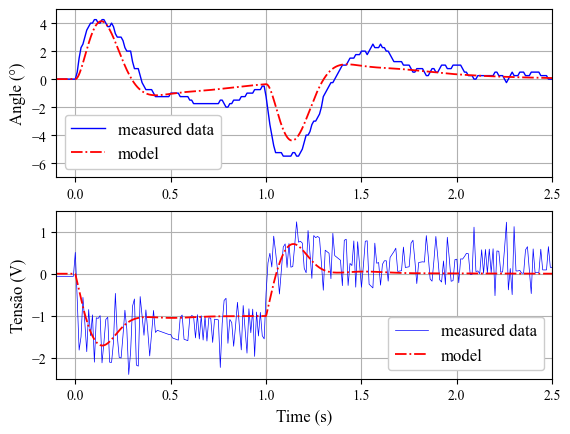

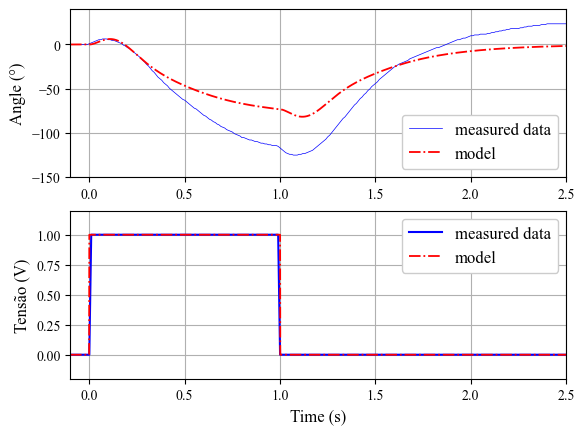

In [15]:
# =========================
# Experimental data - Pulse disturbance
# =========================

# Loads experimental data file
data = np.loadtxt('pulseData.txt')

# Plot limits
x_init = -0.1
x_final = 2.5

# Experimental signals
time = data[:, 0] - 40.02
theta1 = data[:, 1] * 57.296
theta2 = data[:, 2] * 57.296 + 0.25
theta1_dot = data[:, 3] * 57.296
theta2_dot = data[:, 4] * 57.296
input_signal = data[:, 5]
disturbance = data[:, 6]


# Simulation signals (Adjusted time)
time_sim = t[:len(theta1_history)] - 1.0

# =========================
# Figure 1: Pendulum Angle and Control Signal
# =========================
plt.figure()

# Pendulum angle comparison (theta2)
plt.subplot(2, 1, 1)
plt.plot(time, theta2, 'b', linewidth=1)
plt.plot(time_sim, theta2_history, '-.r', linewidth=1.3)

plt.ylabel('Angle (°)', fontsize=12)
plt.legend(['measured data', 'model'], loc='best', fontsize=12, framealpha=1.0)
plt.grid(True, alpha=1.0)
plt.xlim([x_init, x_final])
plt.ylim([-7, 5])

# Control signal comparison
plt.subplot(2, 1, 2)
plt.plot(time, input_signal, 'b', linewidth=0.5)
plt.plot(time_sim, u_history, '-.r', linewidth=1.3)

plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Tensão (V)', fontsize=12)
plt.legend(['measured data', 'model'], loc='best', fontsize=12, framealpha=1.0)
plt.grid(True, alpha=1.0)
plt.xlim([x_init, x_final])
plt.ylim([-2.5, 1.5])

# Saves figure
plt.savefig('pulse1.pdf',
            format='pdf',
            bbox_inches='tight',
            facecolor='white')


# =========================
# Figure 2: Arm Angle and Disturbance
# =========================
plt.figure()

# Arm angle comparison (theta1)
plt.subplot(2, 1, 1)
plt.plot(time, theta1 + 13.5, 'b', linewidth=0.5)
plt.plot(time_sim, theta1_history, '-.r', linewidth=1.3)

plt.ylabel('Angle (°)', fontsize=12)
plt.legend(['measured data', 'model'], loc='best', fontsize=12, framealpha=1.0)
plt.grid(True, alpha=1.0)
plt.xlim([x_init, x_final])
plt.ylim([-150, 40])

# Disturbance comparison
plt.subplot(2, 1, 2)
plt.plot(time + 0.02, disturbance, 'b', linewidth=1.5)
plt.plot(time_sim, disturbance_history, '-.r', linewidth=1.3)

plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Tensão (V)', fontsize=12)
plt.legend(['measured data', 'model'], loc='best', fontsize=12, framealpha=1.0)
plt.grid(True, alpha=1.0)
plt.xlim([x_init, x_final])
plt.ylim([-0.2, 1.2])

# Saves figure
plt.savefig('pulse2.pdf',
            format='pdf',
            bbox_inches='tight',
            facecolor='white')


# Displays all figures
plt.show()

### Comparison between experimental and simulated responses of the system under step disturbance conditions.

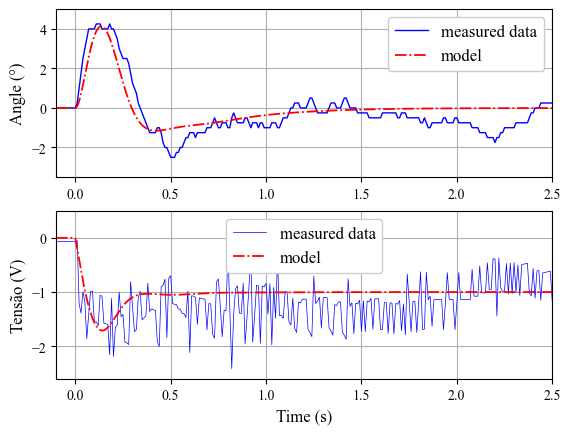

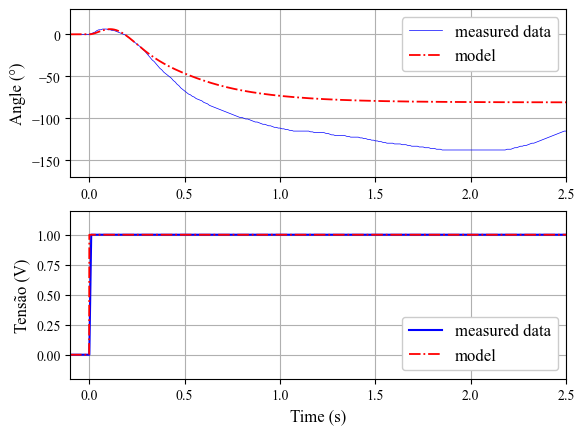

In [13]:
# =========================
# Experimental data - Step disturbance
# =========================

# Loads experimental data file
data_step = np.loadtxt('stepData.txt')

# Plot limits
x_init = -0.1
x_final = 2.5

# Experimental signals
time_step = data_step[:, 0] - 40.02
theta1_step = data_step[:, 1] * 57.296
theta2_step = data_step[:, 2] * 57.296 + 0.25
theta1_dot_step = data_step[:, 3] * 57.296
theta2_dot_step = data_step[:, 4] * 57.296
input_signal_step = data_step[:, 5]
disturbance_step = data_step[:, 6]


# Simulation signals (Adjusted time)
time_sim = t[:len(theta1_history)] - 1.0


# =========================
# Figure 1: Pendulum Angle and Control Signal (Step)
# =========================
plt.figure()

# Pendulum angle comparison (theta2)
plt.subplot(2, 1, 1)
plt.plot(time_step, theta2_step - 2.0, 'b', linewidth=1)
plt.plot(time_sim, theta2_history, '-.r', linewidth=1.3)

plt.ylabel('Angle (°)', fontsize=12)
plt.legend(['measured data', 'model'], loc='best', fontsize=12, framealpha=1.0)
plt.grid(True, alpha=1.0)
plt.xlim([x_init, x_final])
plt.ylim([-3.5, 5])

# Control signal comparison
plt.subplot(2, 1, 2)
plt.plot(time_step, input_signal_step, 'b', linewidth=0.5)
plt.plot(time_sim, u_history, '-.r', linewidth=1.3)

plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Tensão (V)', fontsize=12)
plt.legend(['measured data', 'model'], loc='best', fontsize=12, framealpha=1.0)
plt.grid(True, alpha=1.0)
plt.xlim([x_init, x_final])
plt.ylim([-2.6, 0.5])

# Saves figure
plt.savefig('step1.pdf',
            format='pdf',
            bbox_inches='tight',
            facecolor='white')


# =========================
# Figure 2: Arm Angle and Disturbance (Step)
# =========================
plt.figure()

# Arm angle comparison (theta1)
plt.subplot(2, 1, 1)
plt.plot(time_step, theta1_step - 39.6, 'b', linewidth=0.5)
plt.plot(time_sim, theta1_history, '-.r', linewidth=1.3)

plt.ylabel('Angle (°)', fontsize=12)
plt.legend(['measured data', 'model'], loc='best', fontsize=12, framealpha=1.0)
plt.grid(True, alpha=1.0)
plt.xlim([x_init, x_final])
plt.ylim([-170, 30])

# Disturbance comparison
plt.subplot(2, 1, 2)
plt.plot(time_step + 0.02, disturbance_step, 'b', linewidth=1.5)
plt.plot(time_sim, disturbance_history, '-.r', linewidth=1.3)

plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Tensão (V)', fontsize=12)
plt.legend(['measured data', 'model'], loc='best', fontsize=12, framealpha=1.0)
plt.grid(True, alpha=1.0)
plt.xlim([x_init, x_final])
plt.ylim([-0.2, 1.2])

# Saves figure
plt.savefig('step2.pdf',
            format='pdf',
            bbox_inches='tight',
            facecolor='white')

# Displays all figures
plt.show()